<a href="https://colab.research.google.com/github/zzzer0-wav/myDTA_2026/blob/main/ML/ml_practice_LR%26Cl_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практика: лінійна регресія та класифікація

Це тренувальний блокнот для закріплення базового циклу ML. Завдання **нескладні** й повторюють кроки з основного тьюторіалу — тільки тепер усе робиш **сам**.

**Дві задачі на двох нових наборах даних:**
- **Задача A (регресія):** передбачити **зарплату** працівника.
- **Задача B (класифікація):** передбачити, чи **складе студент іспит** (так/ні).

**Як працювати:**
1. Запусти комірку «Підготовка даних» нижче — вона все налаштує.
2. Іди по кроках. Там, де стоїть `# TODO`, — впиши свій код.
3. Підказки є під кожним кроком.

> 💡 Усі потрібні інструменти ти вже бачив: `train_test_split`, `LinearRegression`, `DecisionTreeClassifier`, `.fit()`, `.predict()`, метрики. Тримай той блокнот поруч як шпаргалку.

---

## 🔧 Підготовка даних (просто запусти)

In [1]:
# ▶️ Просто запусти цю комірку — вона готує дані. Міняти нічого не треба.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 20)

# ---------- Дані A: ЗАРПЛАТИ (для регресії) ----------
N = 800
experience = np.random.randint(0, 31, N)                      # стаж, років
age        = (22 + experience + np.random.randint(0, 12, N)).clip(22, 64)  # вік
education  = np.random.choice([12, 15, 16, 18, 20], N,        # років освіти
                              p=[.2, .15, .35, .2, .1])
english    = np.random.randint(1, 6, N)                       # рівень англ. 1..5

salary = (8000                             # базова ставка, грн
          + experience * 900               # за кожен рік стажу
          + education  * 600               # за рік освіти
          + english    * 1500              # за рівень англійської
          + np.random.normal(0, 3000, N)   # шум: усе інше
         ).clip(8000, None)

salary_df = pd.DataFrame({
    "experience": experience, "age": age,
    "education": education, "english": english,
    "salary": salary.round(0).astype(int),
})

# ---------- Дані B: СТУДЕНТИ (для класифікації) ----------
M = 800
study     = np.random.normal(12, 5, M).clip(0, 30)           # годин навчання/тиждень
attendance= np.random.normal(78, 15, M).clip(30, 100)        # відвідуваність, %
prev_score= np.random.normal(65, 18, M).clip(0, 100)         # бал за минулий іспит
sleep     = np.random.normal(7, 1.2, M).clip(4, 10)          # годин сну

score_logit = (0.12*study + 0.04*attendance + 0.05*prev_score
               + 0.3*sleep - 9 + np.random.normal(0, 1.2, M))
passed = (score_logit > 0).astype(int)                        # 1 = склав, 0 = ні

students_df = pd.DataFrame({
    "study": study.round(1), "attendance": attendance.round(0).astype(int),
    "prev_score": prev_score.round(0).astype(int), "sleep": sleep.round(1),
    "passed": passed,
})

print("✅ Дані готові.")
print("Зарплати:", salary_df.shape, "| Студенти:", students_df.shape)
print("Частка тих, хто склав іспит:", f"{students_df['passed'].mean():.0%}")

✅ Дані готові.
Зарплати: (800, 5) | Студенти: (800, 5)
Частка тих, хто склав іспит: 69%


---
# 🟦 Задача A. Регресія: передбачаємо зарплату

Дані у таблиці `salary_df`. Ознаки: `experience` (стаж), `age` (вік), `education` (років освіти), `english` (рівень англійської 1–5). Ціль: `salary` (зарплата, грн).

Мета — навчити модель передбачати зарплату і **пояснити**, що на неї впливає.

### Крок A1. Подивись на дані
Виведи перші рядки таблиці й описову статистику. Це звичка №1 перед будь-яким навчанням.

*Підказка:* `salary_df.head()` і `salary_df.describe()`.

In [2]:
# TODO: виведи перші рядки salary_df
display(salary_df.head())
# TODO: виведи describe()
print()
display(salary_df.describe())

,experience,age,education,english,salary
0,6,32,15,2,23714
1,19,44,12,3,32814
2,28,54,12,5,54472
3,14,42,20,5,35964
4,10,40,18,2,29723


,experience,age,education,english,salary
count,800.000000,800.000000,800.000000,800.000000,800.000000
mean,15.418750,42.746250,15.856250,3.028750,36028.926250
std,9.328568,9.924338,2.408908,1.432826,9242.043432
min,0.000000,22.000000,12.000000,1.000000,12917.000000
25%,7.000000,35.000000,15.000000,2.000000,28550.750000
50%,16.000000,43.000000,16.000000,3.000000,36102.500000
75%,24.000000,51.000000,18.000000,4.000000,43545.500000
max,30.000000,62.000000,20.000000,5.000000,55947.000000


### Крок A2. Признач ознаки (X) і ціль (y), поділи на train / test
- `X` — усі стовпці, КРІМ `salary`.
- `y` — стовпець `salary`.
- Поділ: 20% у тест, `random_state=RANDOM_STATE`.

*Підказка:* `X = salary_df[["experience", "age", "education", "english"]]`,
`y = salary_df["salary"]`, далі `train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)`.

In [3]:
salary_df.columns

Index(['experience', 'age', 'education', 'english', 'salary'], dtype='object')

In [4]:
from sklearn.model_selection import train_test_split

# TODO: створи X та y
X = salary_df[['experience', 'age', 'education', 'english']]
y = salary_df['salary']

# TODO: поділи на X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

# print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 640 | Test: 160


### Крок A3. Навчи лінійну регресію
Згадай цикл: **створити → `.fit(X_train, y_train)`**.

*Підказка:* `from sklearn.linear_model import LinearRegression`, далі `model = LinearRegression()` і `model.fit(...)`.

In [5]:
from sklearn.linear_model import LinearRegression

# TODO: створи та навчи модель

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### Крок A4. Зроби передбачення й оціни якість
- Передбач на `X_test`.
- Порахуй **MAE** та **R²**.

*Підказка:* `y_pred = model.predict(X_test)`; `mean_absolute_error(y_test, y_pred)`;
`r2_score(y_test, y_pred)`.

In [6]:
from sklearn.metrics import mean_absolute_error, r2_score

# TODO: передбач y_pred
y_pred = model.predict(X_test)


# TODO: порахуй і виведи MAE та R²
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MAE (середняя похибка) = {mae:.2f} грн.')
print(f'R2 = {r2:.2f} (наша модель працює на {r2:.2%} відсотків краще за dummy avg salary to everyone модель)')

MAE (середняя похибка) = 2545.33 грн.
R2 = 0.88 (наша модель працює на 88.15% відсотків краще за dummy avg salary to everyone модель)


### Крок A5. 🔑 Інтерпретуй коефіцієнти
Дістань коефіцієнти моделі й скажи словами, яка ознака найсильніше підвищує зарплату.

*Підказка:* `model.coef_` і `model.intercept_`. Зістав назви з `X.columns`.

In [7]:
# TODO: побудуй таблицю "ознака — коефіцієнт" і відсортуй
coefs = pd.DataFrame({
    'features':X.columns,
    'coef':model.coef_.round(2)
}).sort_values('coef', key=abs, ascending=False)

print(f'Базова ставка: {model.intercept_:.2f} грн.')
print('Коефінієнт впливання:')
coefs

Базова ставка: 6850.03 грн.
Коефінієнт впливання:


,features,coef
3,english,1597.45
0,experience,872.48
2,education,609.59
1,age,31.15


✍️ **Запиши відповідь словами** (просто текстом у цій комірці, подвійний клік):
> Найсильніше на зарплату впливає знання англійської мови, бо коефіцієнт english (1597.45) найбільший за модулем серед усіх ознак. Кожен додатковий рівень знання мови збільшує зп на 1597 грн, що більше ніж влпив додаткового стажу роботи (872.48 грн) або додатковий року освіти (609.59 грн).

### Крок A6. Передбач зарплату для нового працівника
Створи одного працівника й передбач його зарплату: стаж 5, вік 30, освіта 16, англійська 4.

*Підказка:* зроби `pd.DataFrame([{...}])` з тими самими назвами стовпців і передай у `model.predict(...)`.

In [8]:
salary_df.columns

Index(['experience', 'age', 'education', 'english', 'salary'], dtype='object')

In [9]:
# TODO: створи new_employee і передбач зарплату
new_employee = pd.DataFrame([{
    'experience':5,
    'age':30,
    'education':16,
    'english':4
}])

print(f'Даний працівник буде мати зп {model.predict(new_employee)[0].round(2)} грн, mae +- {mae:.2f} грн.')

Даний працівник буде мати зп 28290.19 грн, mae +- 2545.33 грн.


---
# 🟩 Задача B. Класифікація: чи складе студент іспит

Дані у таблиці `students_df`. Ознаки: `study` (годин навчання/тиждень), `attendance` (відвідуваність %), `prev_score` (бал за минулий іспит), `sleep` (годин сну). Ціль: `passed` (1 = склав, 0 = ні).

### Крок B1. Подивись на дані
Виведи перші рядки й перевір баланс класів: яка частка студентів склала іспит?

*Підказка:* `students_df.head()` і `students_df["passed"].mean()`.

In [10]:
# TODO: head() і частка тих, хто склав
display(students_df.head())
print()
print(students_df['passed'].mean().round(2) * 100,'%')

,study,attendance,prev_score,sleep,passed
0,11.2,76,94,5.7,1
1,18.5,72,49,9.4,1
2,15.7,71,59,7.9,0
3,16.1,100,88,5.1,1
4,9.9,92,72,7.0,1



69.0 %


### Крок B2. X, y і поділ на train / test
- `X` — усе, крім `passed`. `y` — `passed`.
- Додай `stratify=y`, щоб пропорція класів збереглася.

*Підказка:* `train_test_split(Xs, ys, test_size=0.2, random_state=RANDOM_STATE, stratify=ys)`.

In [11]:
students_df.columns

Index(['study', 'attendance', 'prev_score', 'sleep', 'passed'], dtype='object')

In [12]:
# TODO: Xs, ys та поділ на Xs_train, Xs_test, ys_train, ys_test
Xs = students_df[['study', 'attendance', 'prev_score', 'sleep']]
ys = students_df['passed']

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    Xs, ys,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=ys
)

### Крок B3. Навчи дерево рішень
Використай `DecisionTreeClassifier` з `max_depth=3` (щоб було просте й читабельне) і `random_state=RANDOM_STATE`.

*Підказка:* `from sklearn.tree import DecisionTreeClassifier`.

In [13]:
from sklearn.tree import DecisionTreeClassifier

# TODO: створи та навчи дерево
tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=RANDOM_STATE
)

tree.fit(Xs_train, ys_train)
ys_pred = tree.predict(Xs_test)

### Крок B4. Передбач і оціни
- Передбач на `Xs_test`.
- Порахуй **accuracy** і побудуй **матрицю плутанини**.

*Підказка:* `accuracy_score(ys_test, ys_pred)` та `confusion_matrix(ys_test, ys_pred)`.

In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix

# TODO: передбач ys_pred, порахуй accuracy та матрицю плутанини

acc = accuracy_score(ys_test, ys_pred)
print(f"Accuracy = {acc:.2%}\n")

cm = confusion_matrix(ys_test, ys_pred)
df_cm = pd.DataFrame(
    cm,
    index=["Насправді не склав", "Насправді склав"],
    columns=["Передбачено не склав", "Передбачено склав"]
)

print("Матриця плутанини:")
display(df_cm)

Accuracy = 75.62%

Матриця плутанини:


,Передбачено не склав,Передбачено склав
Насправді не склав,25,24
Насправді склав,15,96


### Крок B5. Що найбільше впливає на результат?
Виведи важливість ознак дерева й назви найважливішу.

*Підказка:* `tree.feature_importances_`, зістав із `Xs.columns`.

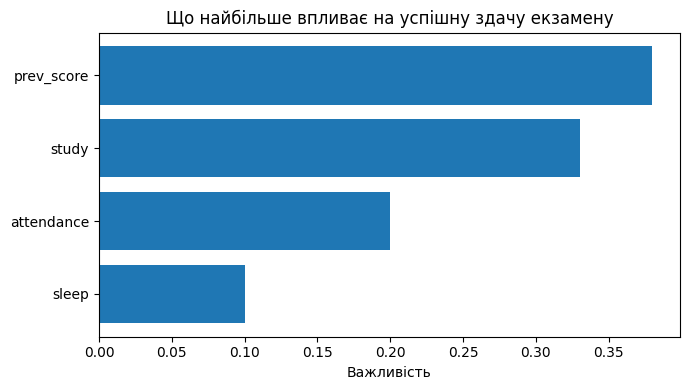

,Ознака,Важливість
3,sleep,0.10
1,attendance,0.20
0,study,0.33
2,prev_score,0.38


In [15]:
# TODO: таблиця "ознака — важливість", відсортована за спаданням
importances = pd.DataFrame({
    'Ознака':Xs.columns,
    'Важливість':tree.feature_importances_.round(2)
}).sort_values('Важливість', ascending=True)

plt.figure(figsize=(7, 4))
plt.barh(importances['Ознака'], importances['Важливість'])

plt.xlabel('Важливість')
plt.title('Що найбільше впливає на успішну здачу екзамену')
plt.tight_layout()
plt.show()

importances

✍️ **Відповідь словами:**
> Найбільше на складання іспиту впливають бали за минулий іспит (0.38), цей показник найкраще відображає загальний рівень підготовки студента, далі йдуть години навчання (0.33), відвідуваність (0.20) і сон (0.10), також важливі але з меншою мірою.

### Крок B6. Передбач для нового студента
Студент: навчання 15 год, відвідуваність 85%, минулий бал 70, сон 7.5.
Виведи і рішення (`predict`), і **ймовірність** скласти (`predict_proba`).

*Підказка:* `predict_proba(...)[0, 1]` — це ймовірність класу «склав».

In [16]:
students_df.columns

Index(['study', 'attendance', 'prev_score', 'sleep', 'passed'], dtype='object')

In [17]:
# TODO: створи new_student, виведи рішення та ймовірність
new_student = pd.DataFrame({
    'study':15,
    'attendance':85,
    'prev_score':70,
    'sleep':7.5
}, index=[0])

pred_model = tree.predict(new_student)[0]
proba = tree.predict_proba(new_student)[0, 1]

print(f"Рішення: {'Здасть' if pred_model else 'Не здасть'}")
print(f"Ймовірність скласти: {proba:.2%}")

Рішення: Здасть
Ймовірність скласти: 88.05%


---
# ⭐ Бонус (необов'язково, але корисно)

1. **Перевір на перенавчання.** Для дерева зі Задачі B порахуй accuracy окремо на `Xs_train` і на `Xs_test`. Великий розрив = зубріння. Потім спробуй `max_depth=10` — розрив зросте?
2. **Сильніша модель.** Навчи `RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)` на тих самих даних і порівняй accuracy з деревом.
3. **Прибери ознаку.** У Задачі A прибери `experience` з `X`, перенавчи й подивись, як впаде R². Який висновок про важливість стажу?

In [19]:
# Місце для бонусних експериментів
acc_train = accuracy_score(ys_train, tree.predict(Xs_train))

acc_test = accuracy_score(ys_test, tree.predict(Xs_test))

print(f'Train accuracy: {acc_train:.2%}')
print(f'Test accuracy: {acc_test:.2%}')
print(f'Розрив: {(acc_train - acc_test):.2%}')\

tree_deep = DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE)
tree_deep.fit(Xs_train, ys_train)

acc_train_deep = accuracy_score(ys_train, tree_deep.predict(Xs_train))
acc_test_deep  = accuracy_score(ys_test,  tree_deep.predict(Xs_test))

print(f"max_depth=10 | Train: {acc_train_deep:.2%} | Test: {acc_test_deep:.2%}")
print(f"Розрив: {(acc_train_deep - acc_test_deep):.2%}")

Train accuracy: 79.22%
Test accuracy: 75.62%
Розрив: 3.59%
max_depth=10 | Train: 97.03% | Test: 71.88%
Розрив: 25.16%


---
# 🧠 Питання на розуміння (без коду)

Дай собі відповідь словами (правильні — у блокноті з розв'язками):
1. Чому ми оцінюємо модель на `X_test`, а не на `X_train`?

Щоб перевірити, як модель працює на нових даних, а не просто запам'ятала тренувальні дані.
___

2. Задача «передбачити кількість проданих квитків» — це регресія чи класифікація? А «спам / не спам»?

Передбачити кількість проданих квитків - це регресія, бо модель прогнозує конкретне число, "спам / не спам" - це класифікація, бо є тільки 2 варіанта, без проміжкових значень.
___

3. Що означає R² = 0.85 простими словами?

Наша модель пояснює 85% розкиду даних. Решта 15% — це випадковий шум, який модель не може передбачити.
___

4. Чому accuracy може бути оманливою, якщо лише 5% студентів провалюють іспит?

Наприклад зі 100 учнів здало 95.
Якщо наша модель завжди буде казати "здасть", вона буде права у 95%, але це не означає, що вона робить щось корисне.
___

5. Коефіцієнт `english = +1500`. Як прочитати це вголос для керівника?

Кожен додатковий бал знання англійської мови додає 1500 грн до очікуваної зарплати, за умови що інші характеристики залишаються незмінними.

> 🎯 Якщо впорався із задачами A і B без підглядання — ти впевнено володієш базовим циклом ML. Вітаю!

🥳🥳🥳